In [7]:
import os
from google import genai

# Securely fetch your API key from an environment variable
GEMINI_API_KEY = "
# Initialize the new client
client = genai.Client(api_key=GEMINI_API_KEY)

# Example: How to generate content with the new client
response = client.models.generate_content(
    model='gemini-2.5-flash', 
    contents='Explain how AI works in a few words.'
)

print(response.text)

AI learns patterns from data to make predictions, decisions, or generate content.


In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset, DatasetDict
import evaluate
from sklearn.preprocessing import LabelEncoder

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch / GPU:", torch.__version__, torch.cuda.is_available(), torch.cuda.device_count())

PyTorch / GPU: 2.5.1 True 1


In [4]:
TRAIN_CSV = "E:/train.csv"
VAL_CSV   = "E:/validation.csv"
TEST_CSV  = "E:/test.csv"

In [5]:
for p in [TRAIN_CSV, VAL_CSV, TEST_CSV]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"{p} not found. Make sure the CSV is uploaded in this path.")

# Quick peek
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("\nSample rows (train):\n", train_df.head())

Train shape: (11118, 3)
Val shape: (1000, 3)
Test shape: (1000, 3)

Sample rows (train):
                                               dialog                    act  \
0  ['Say , Jim , how about going for a few beers ...  [3 4 2 2 2 3 4 1 3 4]   
1  ['Can you do push-ups ? '\n " Of course I can ...          [2 1 2 2 1 1]   
2  ['Can you study with the radio on ? '\n ' No ,...            [2 1 2 1 1]   
3  ['Are you all right ? '\n ' I will be all righ...              [2 1 1 1]   
4  ['Hey John , nice skates . Are they new ? '\n ...    [2 1 2 1 1 2 1 3 4]   

                 emotion  
0  [0 0 0 0 0 0 4 4 4 4]  
1          [0 0 6 0 0 0]  
2            [0 0 0 0 0]  
3              [0 0 0 0]  
4    [0 0 0 0 0 6 0 6 0]  


In [6]:
train_df.head()

,dialog,act,emotion
0,"['Say , Jim , how about going for a few beers ...",[3 4 2 2 2 3 4 1 3 4],[0 0 0 0 0 0 4 4 4 4]
1,"['Can you do push-ups ? '\n "" Of course I can ...",[2 1 2 2 1 1],[0 0 6 0 0 0]
2,"['Can you study with the radio on ? '\n ' No ,...",[2 1 2 1 1],[0 0 0 0 0]
3,['Are you all right ? '\n ' I will be all righ...,[2 1 1 1],[0 0 0 0]
4,"['Hey John , nice skates . Are they new ? '\n ...",[2 1 2 1 1 2 1 3 4],[0 0 0 0 0 6 0 6 0]


In [7]:
import ast
import re
import pandas as pd

def parse_numpy_like_list(s):
    """
    Converts "[1 2 3]" → [1, 2, 3]
    """
    s = s.strip()

    # Convert numpy-like list [1 2 3] → [1,2,3]
    if "[" in s and "]" in s:
        s = re.sub(r"\s+", ", ", s)  # replace spaces with commas
    return ast.literal_eval(s)

In [8]:
def flatten_csv(path, label_type="dialog_act"):
    df = pd.read_csv(path)

    flat_texts = []
    flat_labels = []

    for i, row in df.iterrows():
        # dialog = list of utterances
        texts = ast.literal_eval(row["dialog"])

        # fix numpy-like list
        dialog_labels = parse_numpy_like_list(row["act"])
        emotion_labels = parse_numpy_like_list(row["emotion"])

        if label_type == "dialog_act":
            labels = dialog_labels
        else:
            labels = emotion_labels

        # Flatten
        for t, lab in zip(texts, labels):
            flat_texts.append(t)
            flat_labels.append(lab)
    return pd.DataFrame({"text": flat_texts, "intent": flat_labels})

In [9]:
train_flat = flatten_csv(TRAIN_CSV, label_type="dialog_act")
val_flat   = flatten_csv(VAL_CSV, label_type="dialog_act")
test_flat  = flatten_csv(TEST_CSV, label_type="dialog_act")


In [10]:
train_flat.head()
train_flat.shape

(11118, 2)

In [11]:
train_flat.to_csv("train_flat.csv", index=False)
val_flat.to_csv("val_flat.csv", index=False)
test_flat.to_csv("test_flat.csv", index=False)


In [12]:
TRAIN_CSV = "train_flat.csv"
VAL_CSV   = "val_flat.csv"
TEST_CSV  = "test_flat.csv"

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

train_df.head()


,text,intent
0,"Say , Jim , how about going for a few beers af...",3
1,Can you do push-ups ? Of course I can . It's ...,2
2,"Can you study with the radio on ? No , I list...",2
3,Are you all right ? I will be all right soon ...,2
4,"Hey John , nice skates . Are they new ? Yeah ...",2


In [13]:
le = LabelEncoder()
le.fit(train_df["intent"])

train_df["labels"] = le.transform(train_df["intent"])
val_df["labels"]   = le.transform(val_df["intent"])
test_df["labels"]  = le.transform(test_df["intent"])

# Save label mapping
label_map = {int(i): str(label) for i, label in enumerate(le.classes_)}
with open("label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)

label_map


{0: '1', 1: '2', 2: '3', 3: '4'}

In [14]:
train_ds = Dataset.from_pandas(train_df[["text","labels"]])
val_ds   = Dataset.from_pandas(val_df[["text","labels"]])
test_ds  = Dataset.from_pandas(test_df[["text","labels"]])

datasets = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds
})
datasets


DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 11118
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 1000
    })
})

In [15]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(example):
    return tokenizer(example["text"], truncation=True)

tokenized = datasets.map(preprocess, batched=True)


Map:   0%|          | 0/11118 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [16]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

num_labels = len(le.classes_)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
import evaluate

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"]
    }


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
import torch
print(torch.cuda.is_available())

True


In [20]:
training_args = TrainingArguments(
    output_dir="bert_intent_model",
    eval_strategy="epoch",    # OLD name
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    fp16=True,
)


In [21]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,  # <--- Changed from 'tokenizer'
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.411028,0.385074,0.863000,0.636785
2,0.269444,0.387171,0.869000,0.641102


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1390, training_loss=0.3851865315608841, metrics={'train_runtime': 427.6204, 'train_samples_per_second': 51.999, 'train_steps_per_second': 3.251, 'total_flos': 3418607829802464.0, 'train_loss': 0.3851865315608841, 'epoch': 2.0})

In [22]:
trainer.evaluate(tokenized["test"])


{'eval_loss': 0.38644859194755554,
 'eval_accuracy': 0.867,
 'eval_f1': 0.8479230960982785,
 'eval_runtime': 5.2852,
 'eval_samples_per_second': 189.206,
 'eval_steps_per_second': 6.055,
 'epoch': 2.0}

In [23]:
trainer.save_model("bert_intent_model")
tokenizer.save_pretrained("bert_intent_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_intent_model\\tokenizer_config.json',
 'bert_intent_model\\tokenizer.json')

In [24]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "bert_intent_model"   # change to your folder name

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [25]:
from datasets import Dataset, DatasetDict
import pandas as pd

# Load your CSV (change names as needed)
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "validation": Dataset.from_pandas(val_df),
    "test": Dataset.from_pandas(test_df),
})


In [26]:
print(dataset["train"].column_names)
print(dataset["test"].column_names)


['text', 'intent']
['text', 'intent']


In [27]:
def tokenize(batch):
    return tokenizer(
        batch["text"],      # your text column
        padding=True,
        truncation=True,
        max_length=128
    )

encoded_dataset = dataset.map(tokenize, batched=True)


Map:   0%|          | 0/11118 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [28]:
import pandas as pd

# Load the flattened datasets created in your notebook
train_df = pd.read_csv("train_flat.csv")
val_df = pd.read_csv("val_flat.csv")
test_df = pd.read_csv("test_flat.csv")

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for professional reports
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

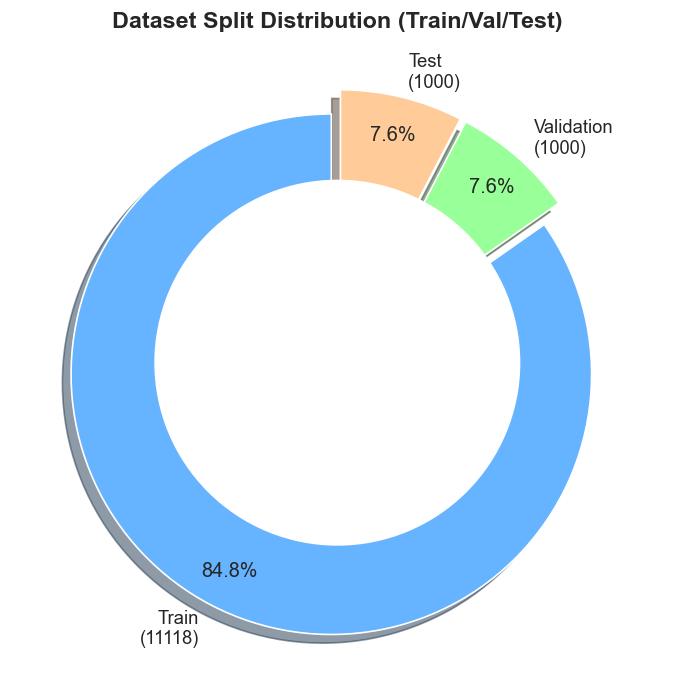

In [30]:
plt.figure(figsize=(8, 6))
sizes = [len(train_df), len(val_df), len(test_df)]
labels = [f'Train\n({len(train_df)})', f'Validation\n({len(val_df)})', f'Test\n({len(test_df)})']
colors = ['#66b3ff', '#99ff99', '#ffcc99']
explode = (0.05, 0.05, 0.05)  # slight separation

plt.pie(sizes, colors=colors, labels=labels, autopct='%1.1f%%', 
        startangle=90, pctdistance=0.85, explode=explode, shadow=True)

# Draw a circle at the center to make it a donut chart (looks more modern)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Dataset Split Distribution (Train/Val/Test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_split_pie.png') # Saves the image
plt.show()

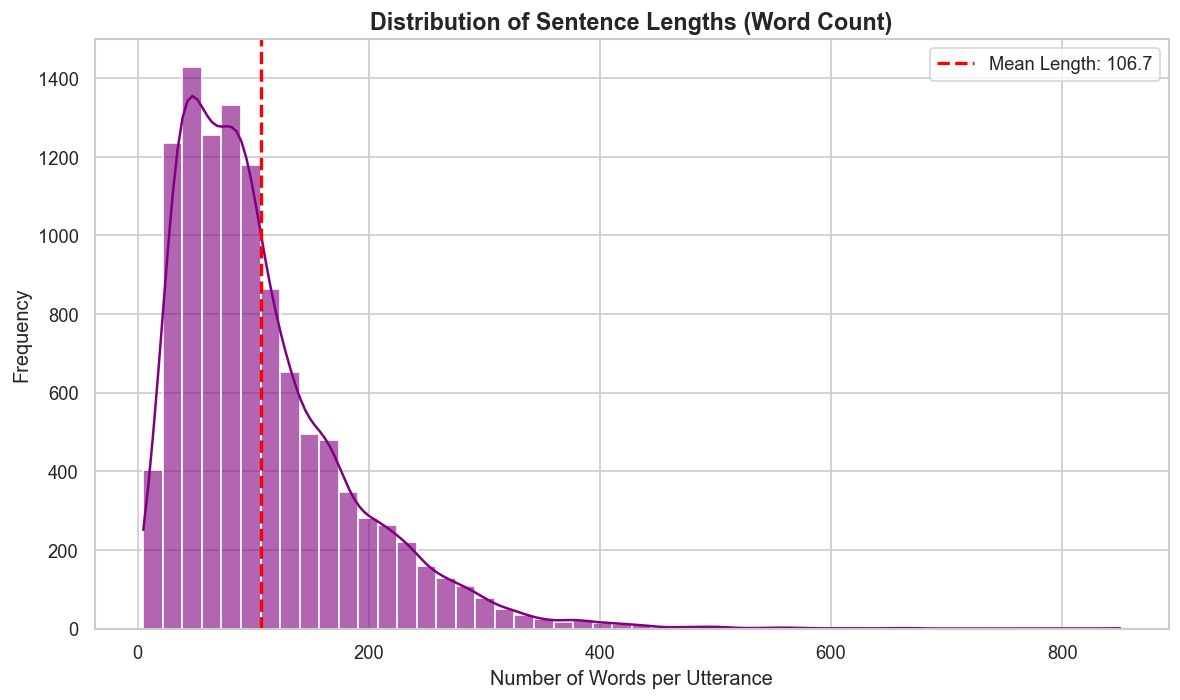

In [33]:
plt.figure(figsize=(10, 6))

# Calculate word counts
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

# Plot Histogram
sns.histplot(train_df['word_count'], bins=50, kde=True, color='purple', alpha=0.6)

# Add a vertical line for the mean length
mean_len = train_df['word_count'].mean()
plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=2, label=f'Mean Length: {mean_len:.1f}')

plt.title('Distribution of Sentence Lengths (Word Count)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words per Utterance', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('sentence_length_hist.png')
plt.show()